<a href="https://colab.research.google.com/github/catarina1532/project_pml/blob/main/land_use_classification_with_resnet_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Land Use Classification of Satellite Imagery Using Transfer Learning with ResNet18 (EuroSAT)

## Importing Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torch import nn
from torch.optim import Adam
from torchvision import models

from sklearn.metrics import classification_report, confusion_matrix

from pathlib import Path

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

## Choosing the Device

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("waseemalastal/eurosat-rgb-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eurosat-rgb-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-rgb-dataset


In [ ]:
from pathlib import Path

dataset_path = Path(path)

for item in dataset_path.iterdir():
    print(item)

/kaggle/input/eurosat-rgb-dataset/EuroSAT_RGB


## Splitting the Data Into Train, Validation and Test Sets

Because the data is not seperated, it should be splitted into Train, Validation and Test sets. To do that, I used splitfolders library and splitted the data into Train, Validation and Test sets by 70%, 20% and 10% respectively.

In [ ]:
dataset_path = Path(path) / "EuroSAT_RGB"

splitfolders.ratio(
    dataset_path,
    output="splitted_data",
    seed=42,
    ratio=(0.7, 0.2, 0.1),
    group_prefix=None,
    move=False
)

Copying files: 27000 files [02:09, 209.08 files/s]


## Data Transformation

Resizing and Normalizing methods are applied to all of the datasets but data augmentation techniques are only applied to Train set in order to richen the data so that the model possibly will yield more accurate results.

In [ ]:
#----------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------- Transformation for the Whole Dataset for Visualization Purposes --------
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## Loading the Data

In [ ]:
train = datasets.ImageFolder(
    root="splitted_data/train",
    transform=train_transform
)

val = datasets.ImageFolder(
    root="splitted_data/val",
    transform=val_transform
)

test = datasets.ImageFolder(
    root="splitted_data/test",
    transform=test_transform
)

# -------- Getting the Whole Dataset for Visualization Purposes --------
data = datasets.ImageFolder(
    root=dataset_path,
    transform=data_transform
)

In [ ]:
print("Dataset Labels:")
print(train.class_to_idx)

idx_to_class = {v:k for k,v in train.class_to_idx.items()}

rows = []

for name, dataset in zip(
    ["Train","Validation","Test"],
    [train,val,test]
):
    counts = pd.Series(dataset.targets).value_counts().sort_index()

    for idx, count in counts.items():
        rows.append([name, idx_to_class[idx], count])

df_counts = pd.DataFrame(
    rows,
    columns=["Dataset","Class","Images"]
)

display(df_counts)

Dataset Labels:
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


,Dataset,Class,Images
0,Train,AnnualCrop,2100
1,Train,Forest,2100
2,Train,HerbaceousVegetation,2100
3,Train,Highway,1750
4,Train,Industrial,1750
5,Train,Pasture,1400
6,Train,PermanentCrop,1750
7,Train,Residential,2100
8,Train,River,1750
9,Train,SeaLake,2100


#### Plotting a few Images

Images plotted below did not undergo a data augmentation process. Therefore, they seem to be normal.

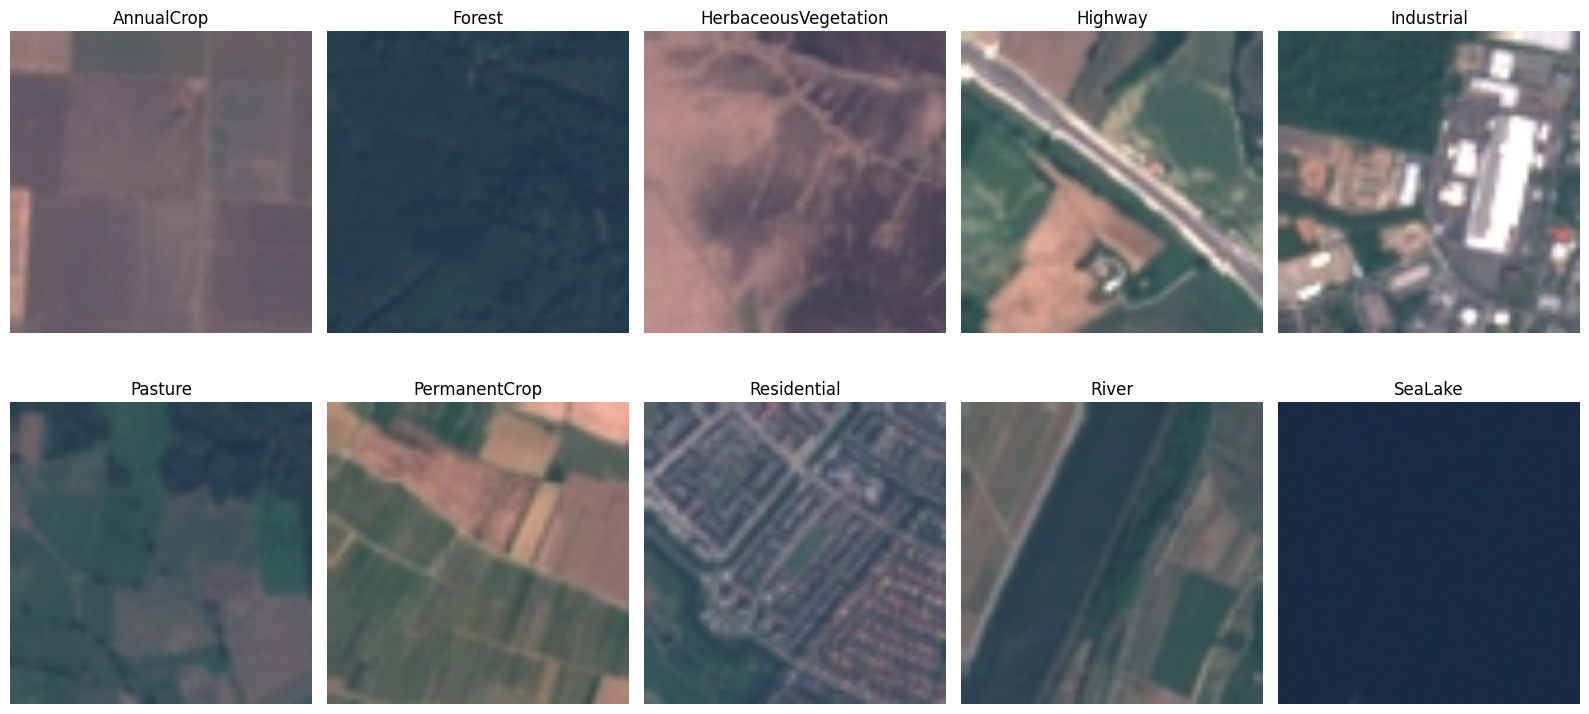

In [ ]:
labels_for_viz = {v: k for k, v in data.class_to_idx.items()}

fig, ax = plt.subplots(2, 5, figsize=(16, 8))
ax = ax.flatten()

for class_idx in range(len(labels_for_viz)):

    for i, (_, label) in enumerate(data):
        if label == class_idx:
            ax[class_idx].imshow(data[i][0].permute(1, 2, 0))
            ax[class_idx].set_title(labels_for_viz[class_idx])
            ax[class_idx].axis("off")
            break

plt.tight_layout()
plt.show()

### Plotting the Augmented Images

Because data augmentation methods are applied to Train set, it can be seen that images are blurred, horizontally and vertically flipped compared to the unaugmented images.

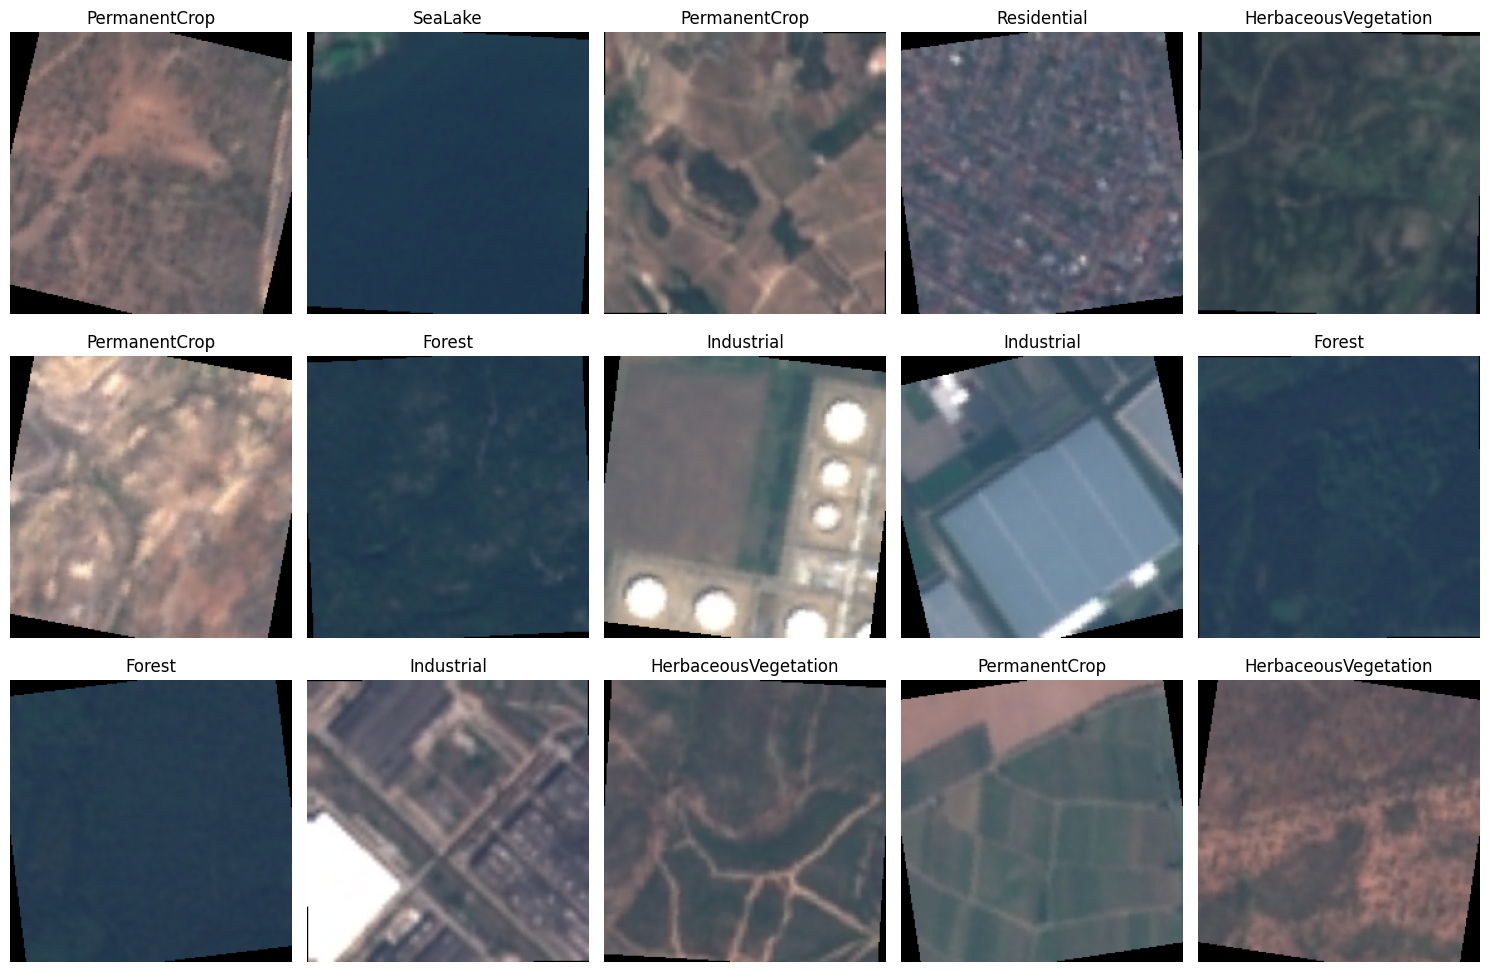

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

fig, ax = plt.subplots(3, 5, figsize=(15, 10))
ax = ax.flatten()

for i in range(15):
    img, label = train[random.randint(0, len(train)-1)]

    img = img.permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)

    ax[i].imshow(img)
    ax[i].set_title(labels_for_viz[label])
    ax[i].axis("off")

plt.tight_layout()
plt.show()

Before passing the data in a neural network, it should be batched and shuffled. Since test will not be used in training process, there is no need to shuffle it.

In [ ]:
train_dataloader = DataLoader(
    train,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_dataloader = DataLoader(
    val,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_dataloader = DataLoader(
    test,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

The EuroSAT dataset contains images belonging to ten land-use and land-cover classes. Since images are organized by class folders, shuffling the training data is important to ensure that the model receives a balanced mixture of classes during training. The labels of a random batch are displayed below to verify that shuffling is working correctly.

In [ ]:
img, label = next(iter(train_dataloader))
print("Batch and Image Shape:", img.shape, "--> [batch_size, color_channels, height, width]")
print("\nLabels:", label)

Batch and Image Shape: torch.Size([32, 3, 224, 224]) --> [batch_size, color_channels, height, width]

Labels: tensor([7, 1, 8, 3, 7, 9, 0, 0, 5, 2, 1, 8, 8, 9, 1, 1, 4, 3, 1, 5, 7, 6, 0, 8,
        5, 3, 3, 4, 6, 9, 9, 4])


## Building the Deep Learning Model

A custom CNN could be designed and trained from scratch for this classification task. However, training deep neural networks from scratch usually requires more computational resources and larger datasets. Therefore, Transfer Learning with a pre-trained ResNet18 model was selected, allowing the network to leverage features learned from ImageNet and adapt them to satellite image classification.

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=131072, out_features=32), # in_features are selected based on the output that Flatten layer yields
            nn.ReLU(),
            nn.Linear(in_features=32, out_features=16),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=4)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x

## Transfer Learning - ResNet18

Transfer learning is a process of utilizing pre-trained machine learning models and applying them to a related task without need of models' learning from scratch for saving time and possibly better performance.

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# 1. congelar tudo
for param in model.parameters():
    param.requires_grad = False

# 2. substituir classifier
model.fc = nn.Linear(model.fc.in_features, 10)

# 3. só FC aprende
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

ResNet18 was pre-trained on the ImageNet dataset. The original classification layer was replaced with a new fully connected layer containing ten output neurons, corresponding to the ten EuroSAT classes. Initially, all convolutional layers were frozen and only the final classification layer was trained.

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Defining the Loss Function and Choosing an Optimizer

In [ ]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.fc.parameters(),
    lr=1e-3,
    momentum=0.9
)

## Defining Train and Test Functions

In [ ]:
def train_and_validate_model(num_epochs):
    val_best_accuracy = 0.0
    train_loss_history = []
    val_loss_history = []
    train_accuracy_history = []
    val_accuracy_history = []

    print("Training begins...")
    for epoch in range(1, num_epochs+1):
        running_train_loss = 0.0
        running_train_accuracy = 0.0
        train_total = 0
        running_val_accuracy = 0.0
        running_val_loss = 0.0
        val_total = 0


        # TRAINING LOOP
        for data in train_dataloader:
            inputs, outputs = data
            inputs, outputs = inputs.to(device), outputs.to(device)
            optimizer.zero_grad()
            predictions = model(inputs)
            train_loss = loss_fn(predictions, outputs)
            _, train_predicted = torch.max(predictions, 1)
            running_train_accuracy += (train_predicted == outputs).sum().item()
            train_total += outputs.size(0)
            train_loss.backward()
            optimizer.step()
            running_train_loss += train_loss.item()

        train_loss_value = running_train_loss/len(train_dataloader)
        train_loss_history.append(train_loss_value)
        train_accuracy = (100*running_train_accuracy)/train_total
        train_accuracy_history.append(train_accuracy)

        # VALIDATION LOOP
        with torch.no_grad():
            model.eval()
            for data in val_dataloader:
                inputs, outputs = data
                inputs, outputs = inputs.to(device), outputs.to(device)
                predictions = model(inputs)
                val_loss = loss_fn(predictions, outputs)

                _, val_predicted = torch.max(predictions, 1)
                running_val_loss += val_loss.item()
                val_total += outputs.size(0)
                running_val_accuracy += (val_predicted == outputs).sum().item()

        val_loss_value = running_val_loss/len(val_dataloader)
        val_loss_history.append(val_loss_value)
        val_accuracy = (100*running_val_accuracy)/val_total
        val_accuracy_history.append(val_accuracy)

        if val_accuracy > val_best_accuracy:
            torch.save(model.state_dict(), "model.pth") # changed path
            val_best_accuracy = val_accuracy

        print("Completed Epoch: ", epoch, "- Training Accuracy: %d" %train_accuracy, "- Validation Accuracy: %d" %val_accuracy, "- Training Loss: %.4f" %train_loss_value, "- Validation Loss: %.4f" %val_loss_value)
    return train_accuracy_history, val_accuracy_history, train_loss_history, val_loss_history

## Fase 1

In [ ]:
EPOCHS_PHASE1 = 5

train_accuracy_history, val_accuracy_history, train_loss_history, val_loss_history = \
train_and_validate_model(EPOCHS_PHASE1)

Training begins...
Completed Epoch:  1 - Training Accuracy: 76 - Validation Accuracy: 82 - Training Loss: 0.8553 - Validation Loss: 0.5876
Completed Epoch:  2 - Training Accuracy: 88 - Validation Accuracy: 85 - Training Loss: 0.4156 - Validation Loss: 0.4685
Completed Epoch:  3 - Training Accuracy: 89 - Validation Accuracy: 86 - Training Loss: 0.3524 - Validation Loss: 0.4271
Completed Epoch:  4 - Training Accuracy: 89 - Validation Accuracy: 88 - Training Loss: 0.3197 - Validation Loss: 0.3710
Completed Epoch:  5 - Training Accuracy: 90 - Validation Accuracy: 88 - Training Loss: 0.3048 - Validation Loss: 0.3565


During the first phase, only the final classification layer was trained. Validation accuracy increased steadily and reached approximately 88%, demonstrating that the pre-trained ImageNet features were already highly informative for the EuroSAT classification task.

After training the final classification layer, the last residual block (layer4) was unfrozen and fine-tuned using a smaller learning rate. This allows the network to adapt high-level image features specifically to satellite imagery while preserving most of the knowledge learned from ImageNet.

## Fase 2

In [ ]:
# Fine-tuning

# descongelar última camada da ResNet
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = torch.optim.SGD(
    model.parameters(),   # agora inclui fc + layer4
    lr=1e-4,              # mais pequeno
    momentum=0.9
)

from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

EPOCHS_PHASE2 = 10

train_accuracy_history2, val_accuracy_history2, train_loss_history2, val_loss_history2 = train_and_validate_model(EPOCHS_PHASE2)

Training begins...
Completed Epoch:  1 - Training Accuracy: 92 - Validation Accuracy: 92 - Training Loss: 0.2266 - Validation Loss: 0.2392
Completed Epoch:  2 - Training Accuracy: 94 - Validation Accuracy: 93 - Training Loss: 0.1779 - Validation Loss: 0.2083
Completed Epoch:  3 - Training Accuracy: 94 - Validation Accuracy: 93 - Training Loss: 0.1571 - Validation Loss: 0.1897
Completed Epoch:  4 - Training Accuracy: 94 - Validation Accuracy: 94 - Training Loss: 0.1474 - Validation Loss: 0.1704
Completed Epoch:  5 - Training Accuracy: 95 - Validation Accuracy: 94 - Training Loss: 0.1289 - Validation Loss: 0.1749
Completed Epoch:  6 - Training Accuracy: 95 - Validation Accuracy: 94 - Training Loss: 0.1212 - Validation Loss: 0.1473
Completed Epoch:  7 - Training Accuracy: 95 - Validation Accuracy: 95 - Training Loss: 0.1105 - Validation Loss: 0.1393
Completed Epoch:  8 - Training Accuracy: 96 - Validation Accuracy: 95 - Training Loss: 0.1075 - Validation Loss: 0.1381
Completed Epoch:  9 -

Fine-tuning the last convolutional block significantly improved performance. Validation accuracy increased from approximately 88% to 95%, showing that adapting high-level feature representations to the satellite imagery domain provides substantial performance gains.

In [ ]:
def test_model():
    model = resnet18(weights=None)   # evita re-download
    model.fc = nn.Linear(512, 10)

    model = model.to(device)

    model.load_state_dict(torch.load("model.pth", map_location=device))
    model.eval()

    running_accuracy = 0
    total = 0
    all_predictions = []

    with torch.no_grad():
        for inputs, outputs in test_dataloader:
            inputs, outputs = inputs.to(device), outputs.to(device)

            predictions = model(inputs)
            _, predicted = torch.max(predictions, 1)

            total += outputs.size(0)
            running_accuracy += (predicted == outputs).sum().item()

            all_predictions.append(predicted.cpu().numpy())

    print("Test Accuracy:", 100 * running_accuracy / total)

    return np.hstack(all_predictions)

## Gráfico Accuracy/Loss

The evolution of training and validation loss and accuracy throughout the learning process is shown below. These curves provide insight into model convergence and possible overfitting.

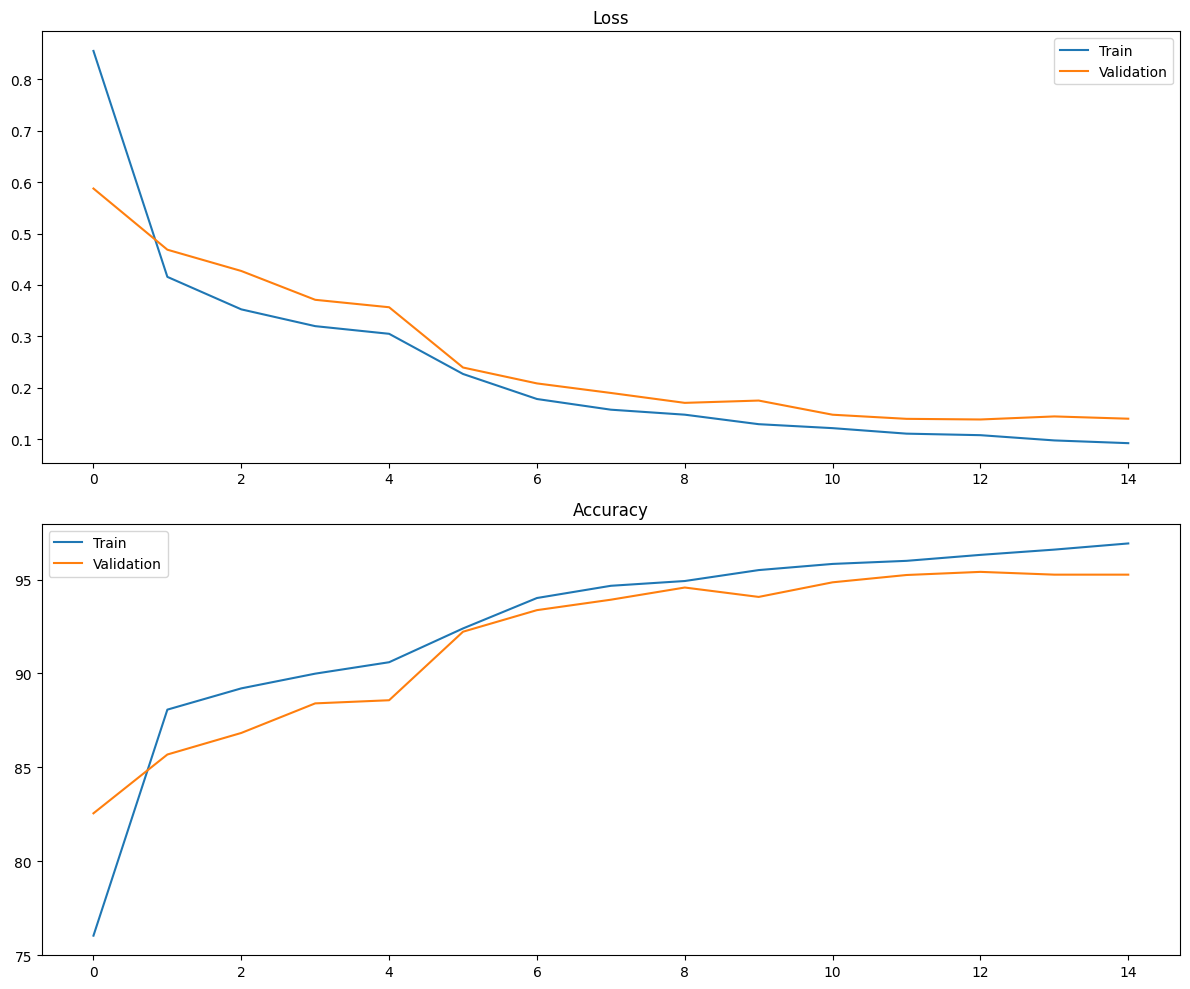

In [ ]:
# gráficos das duas fases juntas

train_acc = train_accuracy_history + train_accuracy_history2
val_acc = val_accuracy_history + val_accuracy_history2

train_loss = train_loss_history + train_loss_history2
val_loss = val_loss_history + val_loss_history2

fig, ax = plt.subplots(2, 1, figsize=(12, 10))
ax = ax.flatten()

ax[0].plot(train_loss, label="Train")
ax[0].plot(val_loss, label="Validation")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(train_acc, label="Train")
ax[1].plot(val_acc, label="Validation")
ax[1].set_title("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

Training and validation curves follow a similar trend, indicating stable learning and limited overfitting. Validation accuracy remained close to training accuracy throughout the training process.

## Classification Report

To evaluate performance in more detail, precision, recall and F1-score were calculated for each EuroSAT class.

In [ ]:
from sklearn.metrics import classification_report

all_preds = test_model()

y_true = np.array(test.targets)
y_pred = np.array(all_preds).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test.class_to_idx.keys())
))

Test Accuracy: 95.48148148148148
                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.92      0.94       300
              Forest       0.98      0.97      0.97       300
HerbaceousVegetation       0.88      0.96      0.92       300
             Highway       0.94      0.94      0.94       250
          Industrial       0.98      0.98      0.98       250
             Pasture       0.97      0.92      0.94       200
       PermanentCrop       0.90      0.90      0.90       250
         Residential       0.99      0.99      0.99       300
               River       0.95      0.98      0.96       250
             SeaLake       0.99      0.97      0.98       300

            accuracy                           0.95      2700
           macro avg       0.96      0.95      0.95      2700
        weighted avg       0.96      0.95      0.95      2700



In [ ]:
print("Macro F1-score:",
      classification_report(
          y_true,
          y_pred,
          output_dict=True
      )["macro avg"]["f1-score"])

Macro F1-score: 0.9539551510567778


The model achieved an overall accuracy of approximately 95%. Classes such as Forest, Residential and SeaLake obtained particularly high scores, while HerbaceousVegetation and PermanentCrop showed slightly lower performance due to visual similarity with other vegetation-related classes.

## Confusion Matrix

A normalized confusion matrix was generated to visualize class-wise prediction performance and identify the most common classification errors.

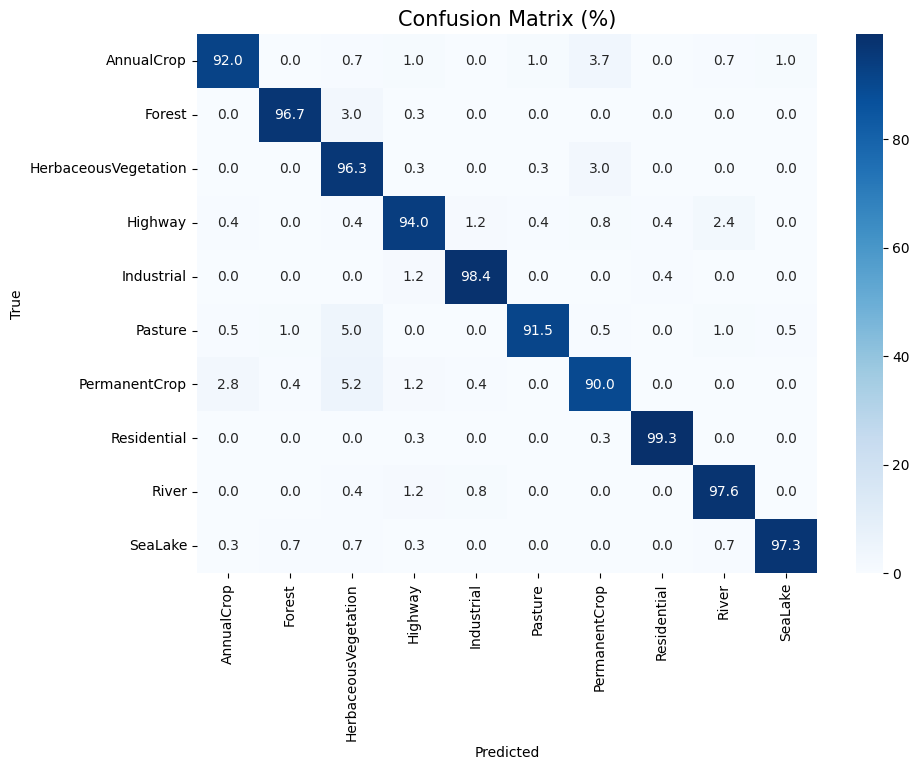

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test.targets, all_preds, normalize='true') * 100

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt=".1f",   # <- CORRETO para floats
    xticklabels=list(test.class_to_idx.keys()),
    yticklabels=list(test.class_to_idx.keys())
)

plt.title("Confusion Matrix (%)", size=15)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Most classes present strong diagonal values, indicating high classification accuracy. Misclassifications mainly occur between visually similar land-cover categories, such as HerbaceousVegetation, Pasture and PermanentCrop.

## Manual Testing

It is always a good practice to test the model manually and try to understand what is going on in prediction. Let's choose a single sample out of test set and make the model predict that single image.

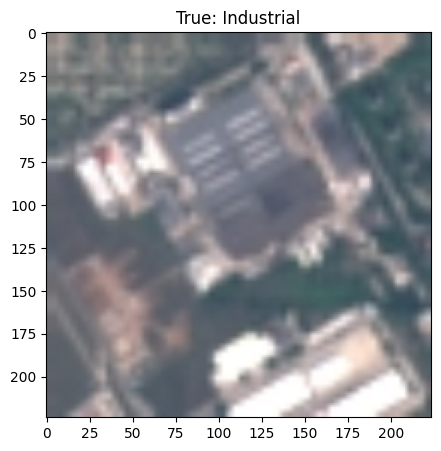

Predicted: Industrial
True: Industrial


In [ ]:
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return image.cpu() * std + mean

idx = random.randint(0, len(test) - 1)

image, label = test[idx]

idx_to_class = {v: k for k, v in test.class_to_idx.items()}

# Visualização correta
plt.figure(figsize=(5,5))
plt.imshow(denormalize(image).permute(1,2,0))
plt.title(f"True: {idx_to_class[label]}")
plt.show()

# Previsão
model.eval()

with torch.no_grad():
    output = model(image.to(device).unsqueeze(0))
    pred = torch.argmax(output, dim=1).item()

print("Predicted:", idx_to_class[pred])
print("True:", idx_to_class[label])

A random image from the test dataset was selected and displayed after reversing the normalization process. The trained model was then used to predict the image class and compare it with the true label.

In this example, the model correctly identified the image as belonging to the Industrial class, demonstrating its ability to generalize to unseen satellite images.